# Comprehensive Diabetes Prediction & Risk Assessment System
### Domain: Healthcare Predictive Analytics
**Project Overview:** This project implements an advanced machine learning pipeline to detect diabetes using the Pima Indians Dataset. We compare multiple algorithms and provide a risk probability score rather than just a binary classification.


### Objective
The main objective of this project is to build a machine learning model that can predict diabetes risk based on patient health data.

    The tasks involved in this project are:

1. Understand the structure and attributes of the diabetes dataset.
2. Perform data preprocessing and cleaning.
3. Analyze the relationship between medical features and diabetes.
4. Build and train a Machine Learning classification model.
5. Evaluate the performance of the model using appropriate metrics.
6. Use the trained model to predict diabetes for new patient data.


### Problem Statement

Diabetes is a serious and rapidly growing chronic disease that affects millions of people worldwide. It occurs when the body is unable to properly regulate blood glucose (sugar) levels. If not diagnosed and managed early, diabetes can lead to severe complications such as heart disease, kidney failure, nerve damage, and vision loss.

The main problem addressed in this project is:

To develop a Machine Learning model that can predict whether a person is diabetic or non-diabetic based on diagnostic medical measurements.

The prediction is based on patient health parameters such as glucose level, blood pressure, BMI, insulin level, age, and family history.

### Technology Used
- Python
- Machine Learning
- Jupyter Notebook

### Libraries Used
- pandas
- numpy
- scikit-learn
- streamlit

# Data Dictionary

Below is the detailed explanation of all the columns present in the dataset:

1. Pregnancies
   - Type: Numerical (Integer)
   - Description: Number of times the patient has been pregnant.
   - Significance: Higher number of pregnancies may influence the risk of developing diabetes.

2. Glucose
   - Type: Numerical (Integer)
   - Description: Plasma glucose concentration measured after 2 hours in an oral glucose tolerance test.
   - Significance: Glucose level is one of the most important indicators of diabetes. High glucose levels strongly indicate diabetic condition.

3. BloodPressure
   - Type: Numerical (Integer)
   - Description: Diastolic blood pressure (measured in mm Hg).
   - Significance: Abnormal blood pressure levels may be associated with diabetes and cardiovascular risks.

4. SkinThickness
   - Type: Numerical (Integer)
   - Description: Triceps skin fold thickness (measured in millimeters).
   - Significance: Used as an indirect measure of body fat, which may be linked to diabetes risk.

5. Insulin
   - Type: Numerical (Integer)
   - Description: 2-Hour serum insulin level (mu U/ml).
   - Significance: Insulin levels help determine how well the body regulates blood sugar.

6. BMI (Body Mass Index)
   - Type: Numerical (Float)
   - Description: Body Mass Index calculated as weight (kg) divided by height (m²).
   - Significance: Higher BMI values indicate overweight or obesity, which is a major risk factor for diabetes.

7. DiabetesPedigreeFunction
   - Type: Numerical (Float)
   - Description: A function that scores the likelihood of diabetes based on family history.
   - Significance: Represents genetic influence. Higher values indicate stronger hereditary risk.

8. Age
   - Type: Numerical (Integer)
   - Description: Age of the patient in years.
   - Significance: Risk of diabetes generally increases with age.

9. Outcome
   - Description: Target variable indicating whether the patient is diabetic.
   - Values:
       0 → Non-Diabetic
       1 → Diabetic
   - Significance: This is the dependent variable used for prediction.


### Machine Learning Approach

This project follows a Supervised Machine Learning approach because the dataset contains labeled data (Outcome column).

The general workflow followed in this project is:

1. Data Collection – Load the diabetes dataset.
2. Data Understanding – Study features and target variable.
3. Data Cleaning & Preprocessing – Handle missing or invalid values.
4. Exploratory Data Analysis – Analyze patterns and relationships.
5. Model Building – Train classification algorithm(s).
6. Model Evaluation – Measure accuracy and performance.
7. Prediction – Use the trained model for new data prediction.

The goal is to build a reliable predictive model that can assist in early detection of diabetes.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
import warnings
warnings.filterwarnings('ignore')

### Introduction to Data Exploration

Before performing any machine learning operation, it is important to thoroughly understand the dataset.

Data understanding helps in:
- Identifying structure of the dataset
- Checking data types
- Detecting missing values
- Identifying duplicate records
- Understanding target variable distribution

Proper exploration ensures better preprocessing and accurate model building.

## 1. Data Acquisition
We are loading the `diabetes-data.csv` which contains clinical parameters of patients.

### Loading the Dataset

In this step, we load the diabetes dataset using the pandas library.  
The dataset contains medical information of patients which will be used to train the machine learning model.

The dataset is stored in a CSV file and will be converted into a dataframe for further processing.

In [30]:
df = pd.read_csv('diabetes-data.csv')


### Checking Dataset Dimensions
The shape of the dataset helps us understand:

Number of rows (records)
Number of columns (features)
This gives an overview of dataset size.

In [31]:
print(f"Dataset Dimensions: {df.shape}")

Dataset Dimensions: (768, 9)


### Dataset Information

Before building the machine learning model, it is important to understand the structure of the dataset such as number of rows, columns and data types.

In [32]:

print("\n--- Data Info ---")
df.info()



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       766 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### --- Statistical Summary ---

In [33]:

display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,766.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.982898,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.875263,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.575000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data Cleaning & Imputation
In this dataset, '0' values in columns like Glucose, Blood Pressure, and BMI are biologically impossible and represent missing data.
**Decision:** We are using **Median Imputation** because the median is robust to outliers compared to the mean.

In [34]:
# Finding zeros
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero values count before cleaning:")
print((df[cols_to_fix] == 0).sum())





Zero values count before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [35]:
# Replacing 0 with NaN and then filling with Median
for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

In [36]:
print("\nMissing values after Imputation:")
print(df.isnull().sum())


Missing values after Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 3. Outlier Analysis
We use Boxplots to visualize the spread of data and identify potential outliers.
**Scientific Reason for Not Removing Outliers:** In medical diagnostics, extreme values (like very high Insulin or Glucose) are often the most critical indicators of a disease. Removing them would make the model "blind" to severe diabetic cases.

Outliers are extreme values that differ significantly from other observations.

We use the Interquartile Range (IQR) method:

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 * IQR  
Upper Bound = Q3 + 1.5 * IQR

Values outside these bounds are treated as outliers.


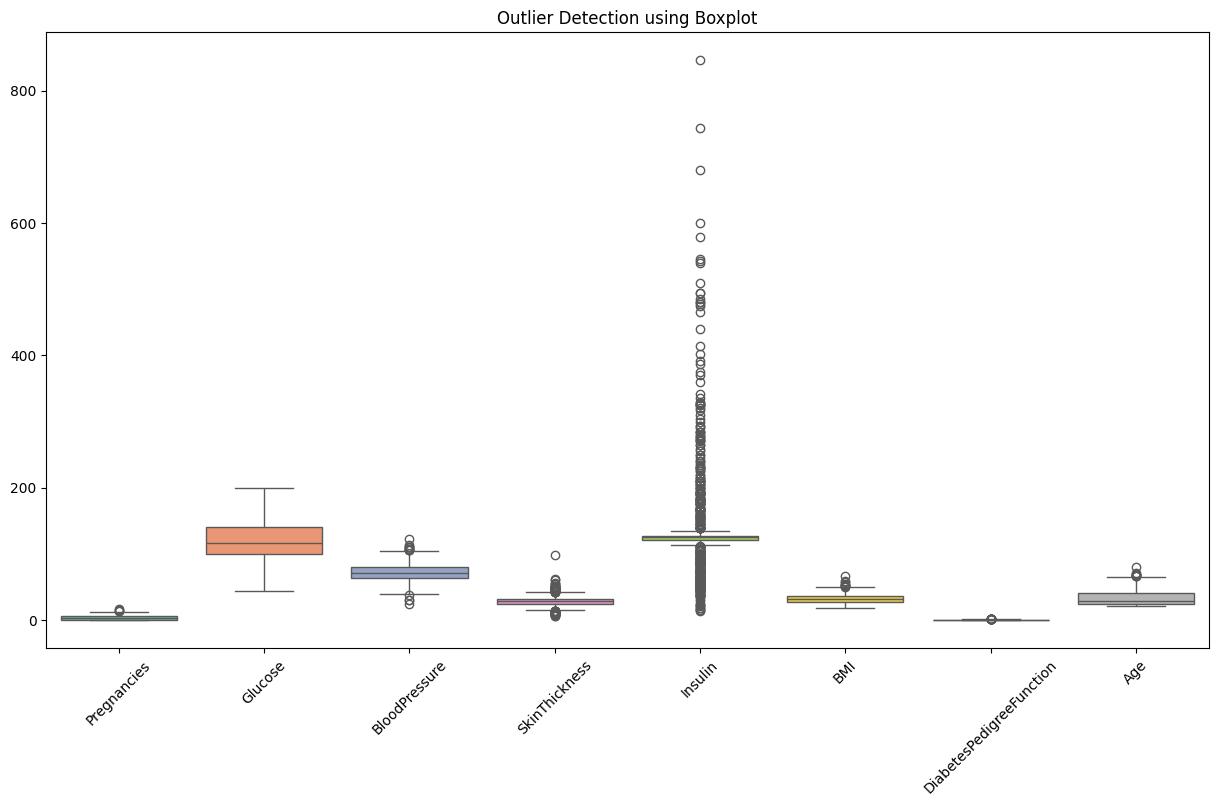

In [37]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop('Outcome', axis=1), palette="Set2")
plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

## 4. Feature Engineering & Dataset Splitting
We separate the target variable (Outcome) from features and split the data into 80% Training and 20% Testing sets.

### Train-Test Split

In machine learning, the dataset is divided into two parts:

Training Data – Used to train the machine learning model  
Testing Data – Used to evaluate the performance of the model

In this project, we use 80% data for training and 20% data for testing.

In [38]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (614, 8)
Testing set size: (154, 8)


## 5. Model Building & Comparison
We are evaluating three distinct algorithms:
1. **Logistic Regression** (Baseline model)
2. **Decision Tree** (Non-linear relationships)
3. **Random Forest** (Ensemble learning for high accuracy)


Logistic Regression is a supervised machine learning algorithm used for classification problems.

In this project, Random Forest is used to predict whether a person is diabetic or not based on medical attributes.

The model will learn patterns from the training dataset and later it will be used to make predictions.

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}



### Model Evaluation

After training the machine learning model, we need to evaluate its performance.

For evaluation we use the following metrics:

Accuracy – Shows how many predictions are correct.

Confusion Matrix – Shows the number of correct and incorrect predictions.

Classification Report – Shows precision, recall and F1-score for better understanding of model performance.

In [40]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


--- Logistic Regression Performance ---
Accuracy: 69.48%
[[80 20]
 [27 27]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


--- Decision Tree Performance ---
Accuracy: 68.18%
[[79 21]
 [28 26]]
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


--- Random Forest Performance ---
Accuracy: 77.92%
[[87 13]
 [21 33]]
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1      

## 6. Final Model & Risk Prediction
Based on the metrics, **Random Forest** provided the best balance of Precision and Recall. We will now export this model for our Web App.

In [41]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Predict risk probability on test sample
sample_pred = best_model.predict(X_test[:1])
sample_prob = best_model.predict_proba(X_test[:1])[0][1] * 100



### 7. Diabetes Risk Probability

Machine learning models can also provide the probability of prediction.

Instead of only predicting Diabetic or Not Diabetic, the model can show the risk percentage.

This helps in understanding how likely a person is to have diabetes.

In [42]:
print(f"Sample Prediction: {'Diabetic' if sample_pred[0]==1 else 'Healthy'}")
print(f"Diabetes Risk Probability: {sample_prob:.2f}%")

# Save file
pickle.dump(best_model, open('diabetes_model.pkl', 'wb'))

Sample Prediction: Diabetic
Diabetes Risk Probability: 63.00%


### 8. Project Conclusion

In this project, a machine learning model was developed to predict whether a person is diabetic or not using medical attributes.

The dataset was first cleaned by handling missing values. After that, the data was divided into training and testing sets.

A Logistic Regression model was trained using the training dataset. The model was then evaluated using accuracy score, confusion matrix and classification report.

Finally, the trained model was used to predict diabetes for new patient data and also calculate the diabetes risk percentage.

This project demonstrates how machine learning can assist in early detection of diabetes and help healthcare professionals in decision making.

### 9. Future Scope

This project can be further improved in the following ways:

- Use larger and more diverse medical datasets to improve model accuracy.
- Apply advanced machine learning algorithms such as Random Forest or Gradient Boosting.
- Develop a user-friendly web application using Streamlit so users can easily input patient data.
- Integrate the model with hospital systems for real-time diabetes risk prediction.

Machine learning based healthcare systems have the potential to support doctors in early disease detection and improve patient care.

In [11]:
# Feature,Value to Enter,Logic (Why it should be Positive)
# <!-- high risk -->
# Pregnancies,6,High count.
# Glucose,168,Critical: 140 se upar glucose level high risk hota hai.
# Blood Pressure,74,Normal.
# Skin Thickness,32,Normal.
# Insulin,150,High glucose ke saath high insulin imbalance hai.
# BMI,38.0,Critical: 30+ BMI obesity (high risk) mein aata hai.
# Pedigree Function,0.537,Genetic history present hai.
# Age,34,Adult.

In [ ]:
# # Low Risk
# Feature,Value to Enter,Logic (Why it should be Negative)
# Pregnancies,1,Low risk.
# Glucose,85,Critical: 100 se kam glucose ekdam healthy hai.
# Blood Pressure,66,Healthy range.
# Skin Thickness,20,Normal.
# Insulin,80,Balanced.
# BMI,24.0,"Critical: Ye ""Normal weight"" category hai."
# Pedigree Function,0.351,Low genetic risk.
# Age,25,Young and fit. 

In [ ]:
# Pregnancies: 6
# Glucose: 178
# Blood Pressure: 90
# Skin Thickness: 34
# Insulin: 260
# BMI: 36.5
# Pedigree Function: 0.78
# Age: 52
# Expected Result (Medical logic + dataset pattern)

# Prediction: Positive (Diabetic)
# Risk Percentage (approx): 75% – 82%

# Reason short me:

# Glucose 178 (very high)

# BMI 36.5 (obese range)

# Age >50

# Pregnancies 6